# 03 Network Building

## Objective
Construct the London Underground graph from cleaned station and connection datasets.

## Inputs
- `data/processed/stations_clean.csv`
- `data/processed/connections_clean.csv`

## Outputs
- in-memory graph objects: `G` and `G_main`
- `outputs/network_graph_main_component.png`

## Why this step matters
This notebook creates the graph representation of the Underground network and isolates the largest connected component for reliable downstream analysis.

In [1]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

stations = pd.read_csv(PROCESSED_DIR / "stations_clean.csv")
connections = pd.read_csv(PROCESSED_DIR / "connections_clean.csv")

## Step 1: Filter to stations that appear in the route connections

Not every station record is guaranteed to appear in the final route edge list. This step keeps only stations that are actually used in the network graph.

In [3]:
used_station_names = set(connections["from_name"]).union(set(connections["to_name"]))
stations_filtered = stations[stations["station_name"].isin(used_station_names)].copy()

print("Original stations:", stations.shape)
print("Filtered stations:", stations_filtered.shape)

Original stations: (293, 6)
Filtered stations: (272, 6)


In [4]:
G = nx.Graph()

for _, row in stations_filtered.iterrows():
    G.add_node(
        row["station_name"],
        station_id=row["station_id"],
        lat=row["lat"],
        lon=row["lon"]
    )

for _, row in connections.iterrows():
    G.add_edge(row["from_name"], row["to_name"], line=row["line"])

## Step 2: Inspect graph structure

This step checks:
- node count
- edge count
- connected components
- isolated nodes

In [5]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))

isolated_nodes = list(nx.isolates(G))
print("Isolated nodes:", len(isolated_nodes))
print(isolated_nodes[:20])

Nodes: 272
Edges: 314
Connected components: 1
Isolated nodes: 0
[]


## Step 3: Extract the largest connected component

The largest connected component is used as the main analysis graph to avoid distortion from disconnected fragments.

In [6]:
largest_component_nodes = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_component_nodes).copy()

print("Main graph nodes:", G_main.number_of_nodes())
print("Main graph edges:", G_main.number_of_edges())
print("Main graph components:", nx.number_connected_components(G_main))

Main graph nodes: 272
Main graph edges: 314
Main graph components: 1


## Step 4: Visualize the main network graph

This plot provides a structural overview of the Underground network after cleaning and graph construction.

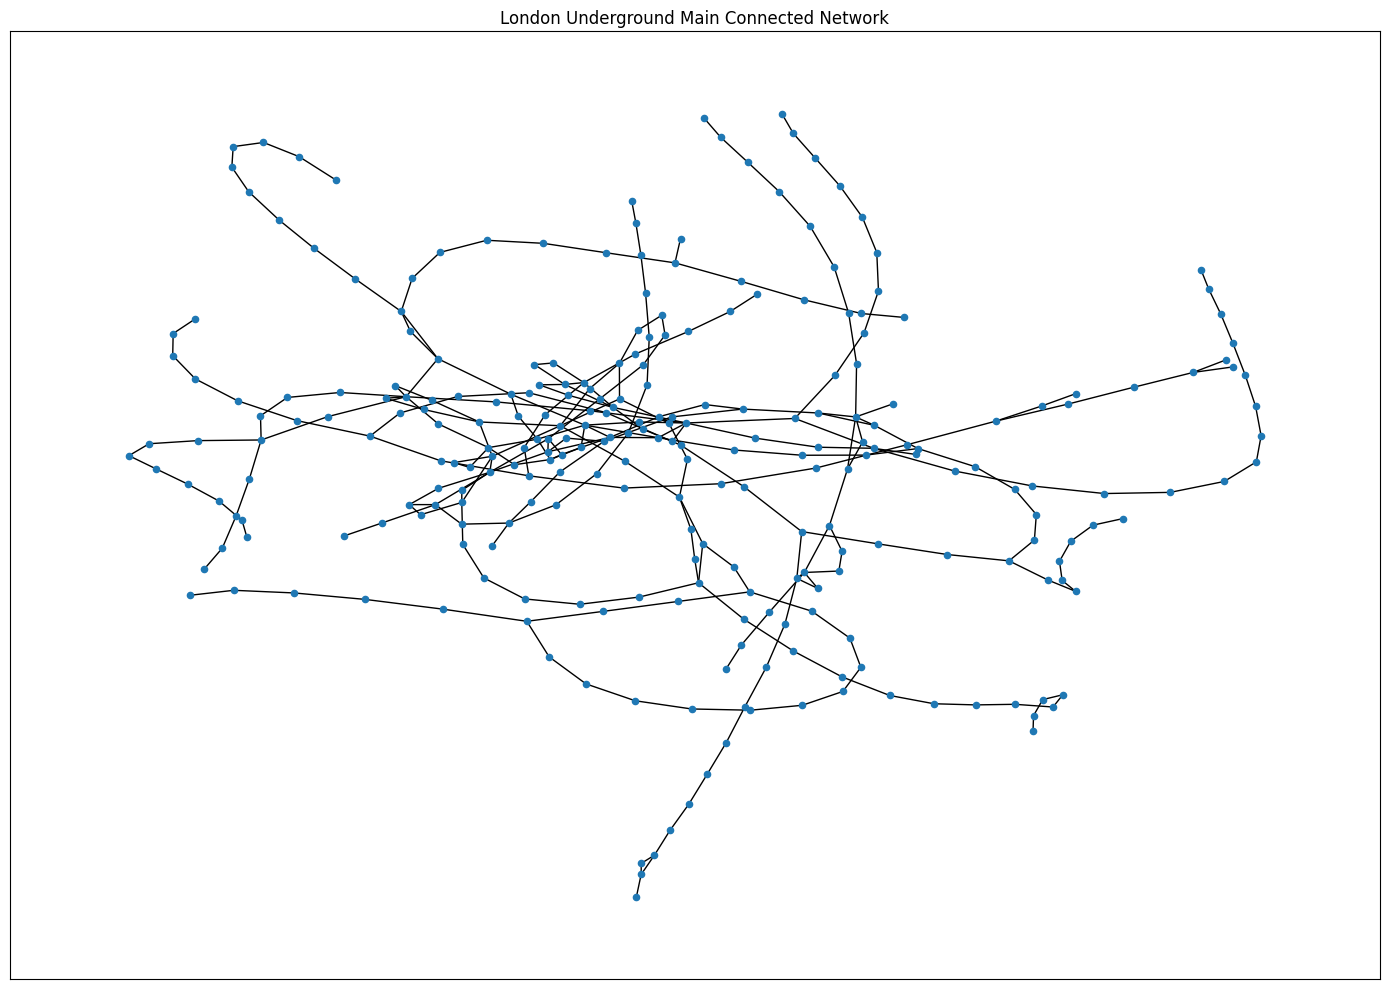

In [7]:
plt.figure(figsize=(14, 10))
nx.draw_networkx(G_main, with_labels=False, node_size=20)
plt.title("London Underground Main Connected Network")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "network_graph_main_component.png")
plt.show()